In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

# 1. 데이터 불러오기
df = pd.read_csv("레포트_데이터.csv")

# 2. 검정할 핵심 변수들 (로그 변환된 M2와 IPI 사용)
target_vars = ['Base_Rate', 'LN_IPI', 'FSI', 'LN_Old_M2', 'LN_New_M2']

# 결과를 담을 리스트
adf_results = []

print("=== 단위근 검정 (ADF Test) 결과 ===")
for var in target_vars:
    # 결측치 제거 후 순수 데이터만 추출
    series = df[var].dropna()

    # --- 1) 원수준(Level) 데이터 검정 ---
    # autolag='AIC'는 컴퓨터가 가장 적절한 시차를 자동으로 찾아주게 하는 옵션입니다.
    p_val_level = adfuller(series, autolag='AIC')[1]

    # --- 2) 1차 차분(First Difference) 데이터 검정 ---
    # .diff()를 통해 '이번 달 - 지난 달'의 변화량만 남깁니다 (거품 제거)
    series_diff = series.diff().dropna()
    p_val_diff = adfuller(series_diff, autolag='AIC')[1]

    adf_results.append({
        '변수명': var,
        '원수준 p-value': round(p_val_level, 4),
        '원수준 판정': '안정(정상성)' if p_val_level < 0.05 else '불안정(단위근 존재)',
        '차분 p-value': round(p_val_diff, 4),
        '차분 판정': '안정(정상성)' if p_val_diff < 0.05 else '불안정(단위근 존재)'
    })

# 데이터프레임으로 예쁘게 출력
df_adf = pd.DataFrame(adf_results)
display(df_adf)

=== 단위근 검정 (ADF Test) 결과 ===


,변수명,원수준 p-value,원수준 판정,차분 p-value,차분 판정
0,Base_Rate,0.1431,불안정(단위근 존재),0.0000,안정(정상성)
1,LN_IPI,0.3546,불안정(단위근 존재),0.0000,안정(정상성)
2,FSI,0.0018,안정(정상성),0.0000,안정(정상성)
3,LN_Old_M2,0.8056,불안정(단위근 존재),0.0009,안정(정상성)
4,LN_New_M2,0.6299,불안정(단위근 존재),0.0613,불안정(단위근 존재)


In [5]:
# 1. 전체 분석 변수 및 차분이 필요한 변수 구분
cols_to_use = ['Base_Rate', 'LN_IPI', 'FSI', 'LN_Old_M2', 'LN_New_M2']
cols_to_diff = ['Base_Rate', 'LN_IPI', 'LN_Old_M2', 'LN_New_M2'] 

# 2. df_stat 데이터프레임 복사 생성
df_stat = df[cols_to_use].copy()

# 3. 차분이 필요한 변수들만 1차 차분 덮어씌우기
df_stat[cols_to_diff] = df_stat[cols_to_diff].diff()

# 4. 결측치 제거 (차분으로 인해 발생한 첫 행의 NaN 제거)
# ※ 이때 FSI_adj의 첫 번째 데이터도 같이 제거되어 모든 변수의 길이가 딱 맞게 조정됩니다.
df_stat = df_stat.dropna()

# 5. 각 모형별 분석 변수명 설정
model_A_vars = ['Base_Rate', 'LN_IPI', 'FSI', 'LN_Old_M2']
model_B_vars = ['Base_Rate', 'LN_IPI', 'FSI', 'LN_New_M2']

# 제대로 만들어졌는지 확인
display(df_stat.head())

,Base_Rate,LN_IPI,FSI,LN_Old_M2,LN_New_M2
1,0.0,0.000000,19.2,0.009904,0.015207
2,0.0,0.018472,18.3,0.004249,0.007938
3,0.0,-0.003333,17.8,0.000578,0.005571
4,0.0,0.048870,17.7,0.007936,0.007500
5,0.0,-0.017643,18.2,0.006929,0.008228


In [7]:
from statsmodels.tsa.stattools import grangercausalitytests
# ==========================================
# 3. 그레인저 인과검정 (시차 3 고정 버전)
# ==========================================

def run_granger_fixed_lag(data, variables, target_lag=3):
    """
    모든 변수 쌍에 대해 특정 시차(target_lag)에서의 인과성을 검정합니다.
    """
    print(f"✅ 설정된 분석 시차(Fixed Lag): {target_lag}")
    print("-" * 50)
    
    for target in variables:
        for predictor in variables:
            if target != predictor:
                # maxlag에 리스트 [target_lag]를 넣으면 해당 시차만 검정합니다.
                test_result = grangercausalitytests(data[[target, predictor]], maxlag=[target_lag], verbose=False)
                
                # 시차 3에서의 ssr_ftest p-value 추출
                p_val = test_result[target_lag][0]['ssr_ftest'][1]
                
                # 유의수준 별표 표시 (0.01: ***, 0.05: **, 0.1: *)
                sig = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.1 else ""
                
                # 결과 출력
                print(f"[{predictor:15} -> {target:15}] p-value: {p_val:.4f} {sig}")

# 실행 시 시차 3을 반영하여 결과 출력
print("\n=== [모형 A] 그레인저 인과검정 (Lag 3 고정) ===")
run_granger_fixed_lag(df_stat, model_A_vars, target_lag=3)

print("\n=== [모형 B] 그레인저 인과검정 (Lag 3 고정) ===")
run_granger_fixed_lag(df_stat, model_B_vars, target_lag=3)


=== [모형 A] 그레인저 인과검정 (Lag 3 고정) ===
✅ 설정된 분석 시차(Fixed Lag): 3
--------------------------------------------------
[LN_IPI          -> Base_Rate      ] p-value: 0.0020 ***
[FSI             -> Base_Rate      ] p-value: 0.0000 ***
[LN_Old_M2       -> Base_Rate      ] p-value: 0.9183 
[Base_Rate       -> LN_IPI         ] p-value: 0.0018 ***
[FSI             -> LN_IPI         ] p-value: 0.0000 ***
[LN_Old_M2       -> LN_IPI         ] p-value: 0.6336 
[Base_Rate       -> FSI            ] p-value: 0.0000 ***
[LN_IPI          -> FSI            ] p-value: 0.0079 ***
[LN_Old_M2       -> FSI            ] p-value: 0.9733 
[Base_Rate       -> LN_Old_M2      ] p-value: 0.0152 **
[LN_IPI          -> LN_Old_M2      ] p-value: 0.2669 
[FSI             -> LN_Old_M2      ] p-value: 0.1399 

=== [모형 B] 그레인저 인과검정 (Lag 3 고정) ===
✅ 설정된 분석 시차(Fixed Lag): 3
--------------------------------------------------
[LN_IPI          -> Base_Rate      ] p-value: 0.0020 ***
[FSI             -> Base_Rate      ] p-value: 0

In [8]:
from statsmodels.tsa.api import VAR
# ==========================================
# 4. VAR 모형 시차(Lag) 결정 - 수정본
# ==========================================

def suggest_var_order(data, variables, model_name, maxlag=12): # 여기 인자 이름은 마음대로 정해도 됩니다.
    print(f"\n" + "="*50)
    print(f"       {model_name} 시차 선택 진단 (Max Lags: {maxlag})")
    print("="*50)
    
    # 해당 모형의 변수들만 추출
    var_data = data[variables]
    
    # VAR 모델 초기화
    model = VAR(var_data)
    
    # ⚠️ 수정된 부분: maxlag -> maxlags
    results = model.select_order(maxlags=maxlag) 
    
    # 1. 상세 결과 표 출력 (AIC, BIC, FPE, HQIC)
    print(results.summary())
    
    # 2. 주요 기준별 최적 시차 요약
    print(f"\n💡 [추천] {model_name} 최적 시차 요약:")
    print(f"   - AIC: {results.aic}")
    print(f"   - BIC: {results.bic}")
    print(f"   - HQIC: {results.hqic}")
    
    return results

# 다시 실행
order_results_a = suggest_var_order(df_stat, model_A_vars, "모형 A")
order_results_b = suggest_var_order(df_stat, model_B_vars, "모형 B")


       모형 A 시차 선택 진단 (Max Lags: 12)
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -18.04      -17.99   1.462e-08      -18.02
1       -20.99      -20.71   7.678e-10      -20.88
2       -22.05      -21.55   2.661e-10      -21.85
3       -22.33     -21.61*   2.003e-10     -22.04*
4       -22.35      -21.41   1.967e-10      -21.97
5       -22.34      -21.18   1.987e-10      -21.87
6      -22.39*      -21.00  1.902e-10*      -21.83
7       -22.33      -20.73   2.008e-10      -21.69
8       -22.30      -20.47   2.086e-10      -21.56
9       -22.24      -20.19   2.205e-10      -21.42
10      -22.25      -19.98   2.186e-10      -21.34
11      -22.21      -19.72   2.288e-10      -21.21
12      -22.21      -19.50   2.300e-10      -21.12
--------------------------------------------------

💡 [추천] 모형 A 최적 시차 요약:
   - AIC: 6
   - BIC: 3
   - HQIC: 3

       모형 B 시차 선택 진단 (Max Lags: 12)

In [9]:
# ==========================================
# 4. VAR 모형 적합 (Vector Autoregression) - BIC 기준 수정본
# ==========================================
def run_var_model(data, variables, model_name):
    print(f"\n" + "="*50)
    print(f"           {model_name} VAR 모형 결과 (BIC 기준)")
    print("="*50)
    
    # 모델에 사용할 데이터만 추출
    var_data = data[variables]
    
    # VAR 객체 생성
    model = VAR(var_data)
    
    try:
        # 정보기준 탐색 (최대 10시차까지)
        lag_results = model.select_order(maxlags=10)
        
        # AIC 대신 BIC를 사용하여 최적 시차 선택
        optimal_lag = lag_results.bic
        
        print(f"💡 BIC 기준 최적 시차(Lag Order): {optimal_lag}")
        print(f"   (참고 - AIC 기준 시차: {lag_results.aic})") # 비교를 위해 출력
        
    except Exception as e:
        print(f"💡 시차 선택 중 오류 발생: {e}. 기본 시차 1로 진행합니다.")
        optimal_lag = 1
        
    if optimal_lag == 0:
        print("💡 BIC가 0을 추천했으나, 분석을 위해 최소 시차인 1을 적용합니다.")
        optimal_lag = 1
        
    # 선택된 최적 시차로 VAR 모형 훈련
    fitted_model = model.fit(optimal_lag)
    
    # 모델 요약 결과 출력
    print(fitted_model.summary())
    return fitted_model

# 수정된 함수로 모형 실행
var_model_a = run_var_model(df_stat, model_A_vars, "모형 A")
var_model_b = run_var_model(df_stat, model_B_vars, "모형 B")


           모형 A VAR 모형 결과 (BIC 기준)
💡 BIC 기준 최적 시차(Lag Order): 3
   (참고 - AIC 기준 시차: 6)
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 28, Apr, 2026
Time:                     23:33:05
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -21.6551
Nobs:                     265.000    HQIC:                  -22.0753
Log likelihood:           1510.29    FPE:                1.95162e-10
AIC:                     -22.3575    Det(Omega_mle):     1.61139e-10
--------------------------------------------------------------------
Results for equation Base_Rate
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.021095         0.025106            0.840           0.401
L1.Base_Rate        -0.007004         0.064571      


✅ 모형 A (Old M2) 적합 완료 (Selected Lag: 3)


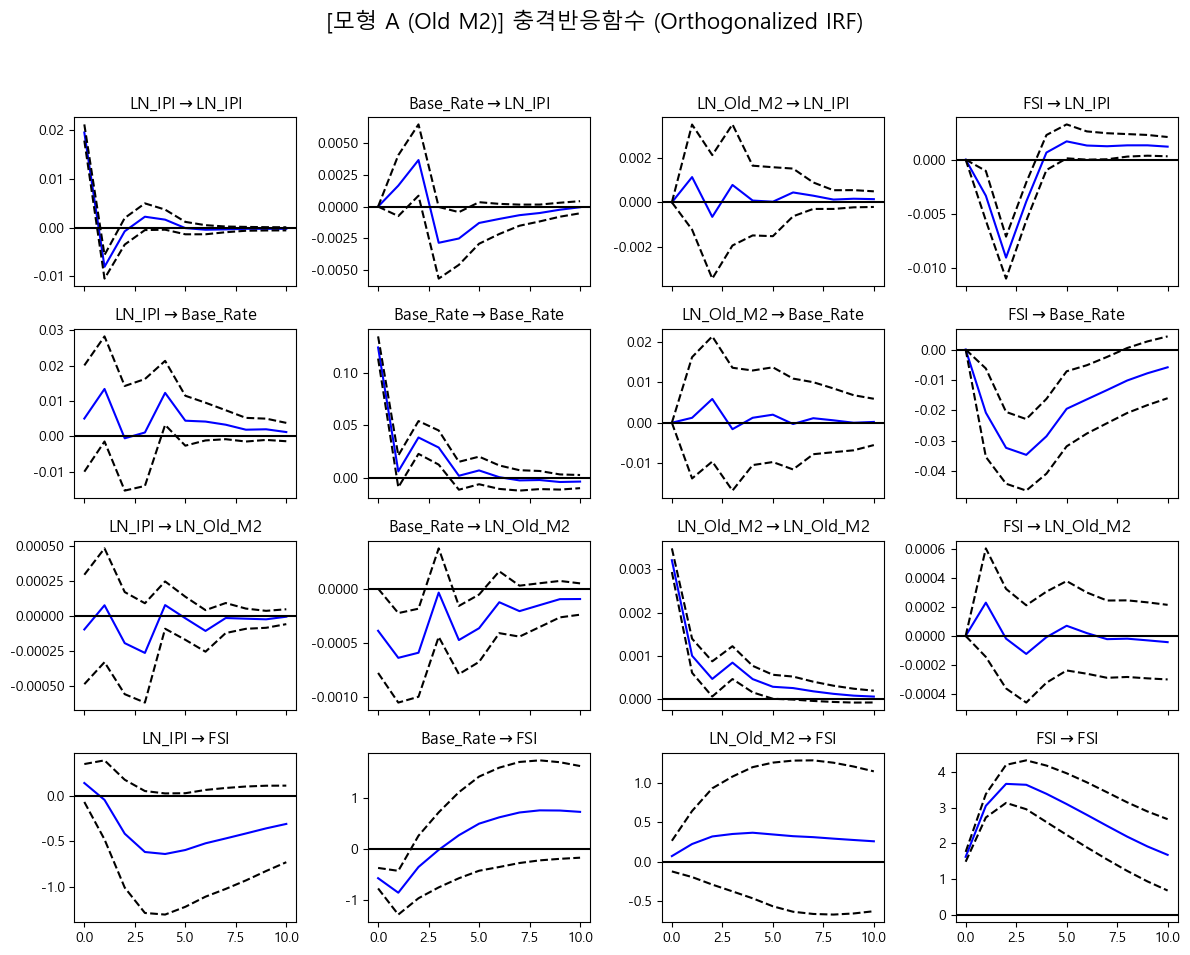


✅ 모형 B (New M2) 적합 완료 (Selected Lag: 3)


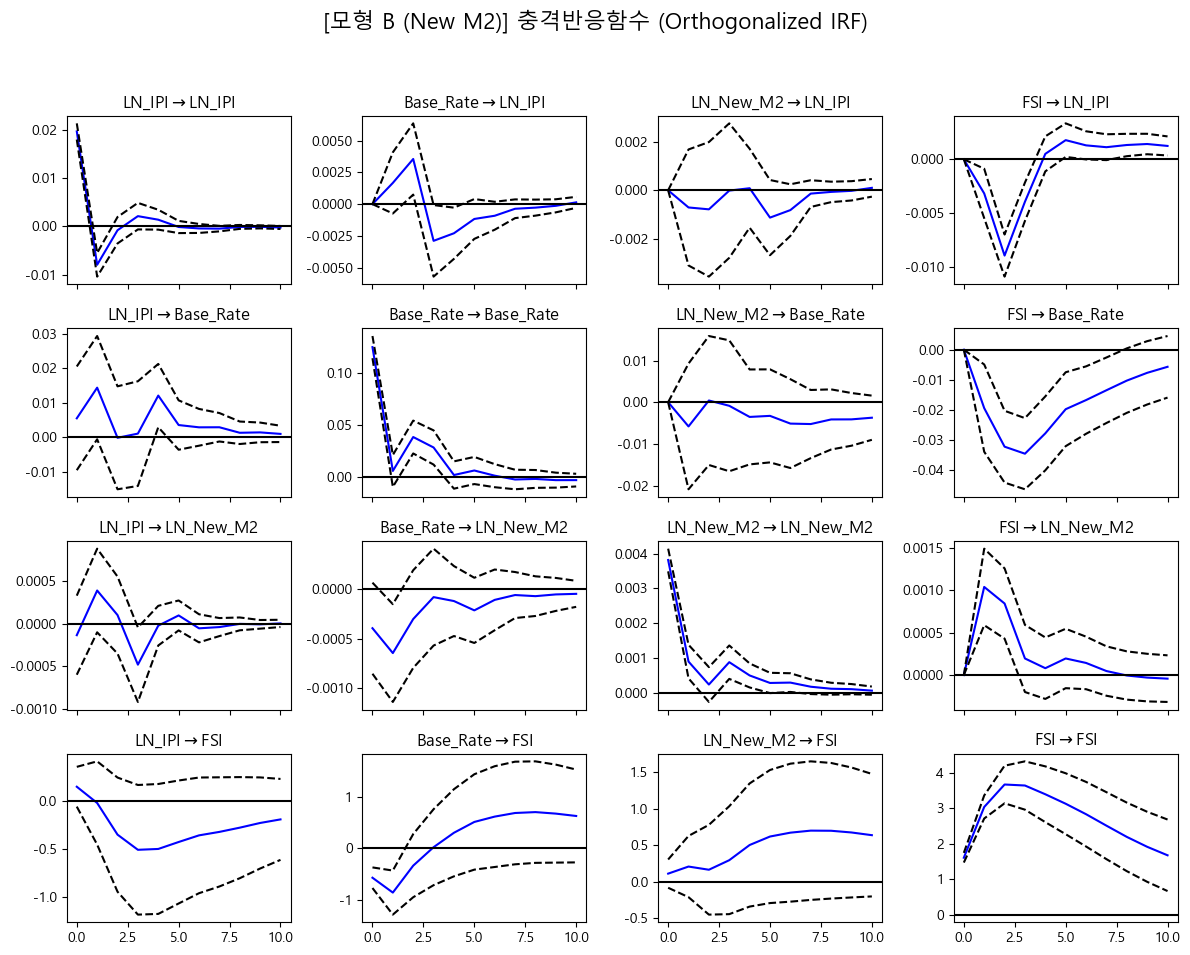

In [11]:
import matplotlib.pyplot as plt

# 한글 깨짐 방지 (Windows 기준, Mac은 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def plot_var_irf(data, variables, model_name, periods=10):
    """
    VAR 모형을 적합하고 충격반응함수(IRF)를 그리는 함수
    variables: 경제학적 논리에 따라 순서가 조정된 변수 리스트
    """
    # 1. 데이터 추출 및 모델 적합
    var_data = data[variables]
    model = VAR(var_data)
    
    # BIC 기준으로 최적 시차 선택
    lag_results = model.select_order(maxlags=10)
    optimal_lag = lag_results.bic if lag_results.bic > 0 else 1
    
    fitted_model = model.fit(optimal_lag)
    print(f"\n✅ {model_name} 적합 완료 (Selected Lag: {optimal_lag})")

    # 2. 충격반응함수(IRF) 계산
    # 숄레스키 분해(Orthogonalized IRF)가 기본으로 적용됨
    irf = fitted_model.irf(periods=periods)

    # 3. 시각화
    # 모든 변수의 상호작용을 다 그리면 너무 복잡하므로, 
    # 보통 '충격(Shock)'을 주는 핵심 변수들을 선택해서 그립니다.
    # 여기서는 모든 변수에 대한 충격 반응을 확인합니다.
    fig = irf.plot(orth=True, figsize=(12, 10))
    plt.suptitle(f"[{model_name}] 충격반응함수 (Orthogonalized IRF)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    return fitted_model

# ==========================================
# 4. 변수 순서 재배치 (Cholesky Ordering 반영)
# 순서: 실물(IPI) -> 정책(금리) -> 통화량(M2) -> 금융시장(FSI)
# ==========================================
ordered_vars_A = ['LN_IPI', 'Base_Rate', 'LN_Old_M2', 'FSI']
ordered_vars_B = ['LN_IPI', 'Base_Rate', 'LN_New_M2', 'FSI']

# 모형 A 실행 및 IRF 출력
fitted_A = plot_var_irf(df_stat, ordered_vars_A, "모형 A (Old M2)")

# 모형 B 실행 및 IRF 출력
fitted_B = plot_var_irf(df_stat, ordered_vars_B, "모형 B (New M2)")